# Garbage Classification with EfficientNetB0

This notebook keeps the same workflow as `notebookef12808083`, but replaces the ResNet50 backbone with `EfficientNetB0`, following the stronger transfer-learning setup from `Garbage_Classification_Clean.ipynb`.

In [35]:
import os
import json
from pathlib import Path

import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.metrics import classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [36]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)

# Original notebook path + common Kaggle fallback paths.
possible_data_dirs = [
    Path("/kaggle/input/datasets/namanjain001/garbage-classification-dataset/Final Dataset"),
    Path("/kaggle/input/garbage-classification-dataset/Final Dataset"),
    Path("/kaggle/input/garbage-classification-dataset/Garbage Classification"),
    Path("/kaggle/input/garbage-classification-dataset"),
]

DATA_DIR = next((p for p in possible_data_dirs if p.exists()), possible_data_dirs[0])
print("Using DATA_DIR:", DATA_DIR)

if not DATA_DIR.exists():
    raise FileNotFoundError(
        "Dataset folder was not found. Update DATA_DIR to the folder that contains the class folders."
    )

Using DATA_DIR: /kaggle/input/datasets/namanjain001/garbage-classification-dataset/Final Dataset


In [37]:
train_ds = keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.30,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

temp_ds = keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.30,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

# Split the 30% temporary set into 15% validation and 15% test.
val_size = int(0.5 * len(temp_ds))
val_ds = temp_ds.take(val_size)
test_ds = temp_ds.skip(val_size)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)
print("Train batches:", len(train_ds))
print("Validation batches:", len(val_ds))
print("Test batches:", len(test_ds))

Found 8775 files belonging to 10 classes.
Using 6143 files for training.
Found 8775 files belonging to 10 classes.
Using 2632 files for validation.
Classes: ['battery', 'biological', 'brown-glass', 'cardboard', 'green-glass', 'metal', 'paper', 'plastic', 'trash', 'white-glass']
Number of classes: 10
Train batches: 192
Validation batches: 41
Test batches: 42


In [38]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

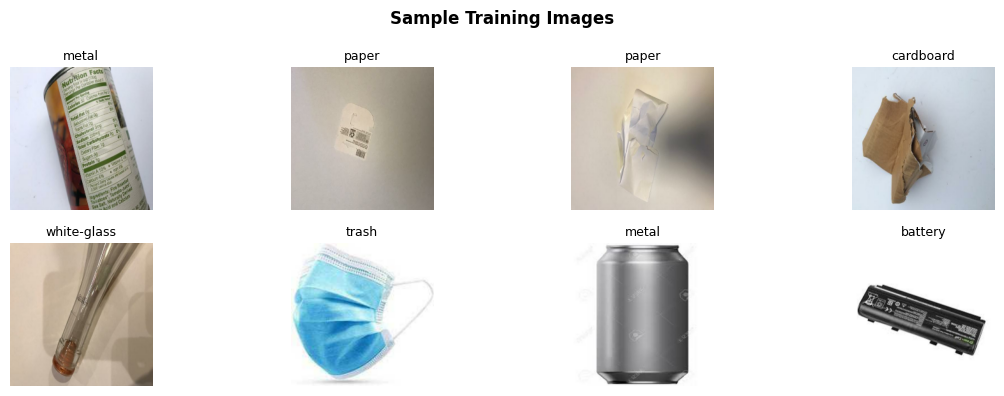

In [39]:
plt.figure(figsize=(12, 4))
for images, labels in train_ds.take(1):
    for i in range(min(8, images.shape[0])):
        plt.subplot(2, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[int(labels[i])], fontsize=9)
        plt.axis("off")
plt.suptitle("Sample Training Images", fontweight="bold")
plt.tight_layout()
plt.show()

In [40]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomBrightness(0.2),
    layers.RandomContrast(0.2),
], name="data_augmentation")

In [41]:
# EfficientNetB0 expects images in the normal [0, 255] pixel range.
# Its Keras implementation already includes the required internal preprocessing.
base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
)

base_model.trainable = False

In [42]:
inputs = keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

x = data_augmentation(inputs)
x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(num_classes, activation="softmax")(x)

model = keras.Model(inputs, outputs, name="garbage_efficientnetb0")

In [43]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

callbacks_phase1 = [
    EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True,
        verbose=1,
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3,
        min_lr=1e-6,
        verbose=1,
    ),
    ModelCheckpoint(
        "best_efficientnetb0_phase1.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1,
    ),
]

model.summary()

Model: "garbage_efficientnetb0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,416,813 (16.85 MB)

 Trainable params: 364,682 (1.39 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [44]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks_phase1,
)

Epoch 1/20


E0000 00:00:1779008499.993183      57 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/garbage_efficientnetb0_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.5695 - loss: 1.3615
Epoch 1: val_accuracy improved from -inf to 0.90549, saving model to best_efficientnetb0_phase1.keras
192/192 ━━━━━━━━━━━━━━━━━━━━ 33s 112ms/step - accuracy: 0.5702 - loss: 1.3594 - val_accuracy: 0.9055 - val_loss: 0.3407 - learning_rate: 0.0010
Epoch 2/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.8086 - loss: 0.5910
Epoch 2: val_accuracy improved from 0.90549 to 0.92530, saving model to best_efficientnetb0_phase1.keras
192/192 ━━━━━━━━━━━━━━━━━━━━ 19s 98ms/step - accuracy: 0.8087 - loss: 0.5909 - val_accuracy: 0.9253 - val_loss: 0.2333 - learning_rate: 0.0010
Epoch 3/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.8458 - loss: 0.4812
Epoch 3: val_accuracy improved from 0.92530 to 0.92607, saving model to best_efficientnetb0_phase1.keras
192/192 ━━━━━━━━━━━━━━━━━━━━ 19s 97ms/step - accuracy: 0.8458 - loss: 0.4812 - val_accuracy: 0.9261 - val_loss: 0.2116 - learning_rate: 0.0010
Epoch 4/

In [45]:
# Fine-tune only the last 30 layers of EfficientNetB0.
base_model.trainable = True

for layer in base_model.layers[:-60]:
    layer.trainable = False

trainable_layers = sum(1 for layer in base_model.layers if layer.trainable)
print(f"Trainable EfficientNetB0 layers: {trainable_layers} / {len(base_model.layers)}")

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

callbacks_phase2 = [
    EarlyStopping(
        monitor="val_accuracy",
        patience=6,
        restore_best_weights=True,
        verbose=1,
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3,
        min_lr=1e-7,
        verbose=1,
    ),
    ModelCheckpoint(
        "best_efficientnetb0_phase2.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1,
    ),
]

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks_phase2,
)

Trainable EfficientNetB0 layers: 60 / 238
Epoch 1/20


E0000 00:00:1779008811.345076      57 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/garbage_efficientnetb0_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.8223 - loss: 0.5606
Epoch 1: val_accuracy improved from -inf to 0.93140, saving model to best_efficientnetb0_phase2.keras
192/192 ━━━━━━━━━━━━━━━━━━━━ 45s 141ms/step - accuracy: 0.8223 - loss: 0.5606 - val_accuracy: 0.9314 - val_loss: 0.2257 - learning_rate: 1.0000e-05
Epoch 2/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.8488 - loss: 0.4800
Epoch 2: val_accuracy did not improve from 0.93140
192/192 ━━━━━━━━━━━━━━━━━━━━ 24s 123ms/step - accuracy: 0.8488 - loss: 0.4800 - val_accuracy: 0.9223 - val_loss: 0.2426 - learning_rate: 1.0000e-05
Epoch 3/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.8480 - loss: 0.4538
Epoch 3: val_accuracy did not improve from 0.93140
192/192 ━━━━━━━━━━━━━━━━━━━━ 23s 121ms/step - accuracy: 0.8480 - loss: 0.4537 - val_accuracy: 0.9291 - val_loss: 0.2268 - learning_rate: 1.0000e-05
Epoch 4/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.8628 - loss: 0.4132
Epoch 4: va

In [46]:
test_loss, test_acc = model.evaluate(test_ds, verbose=1)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test accuracy (%): {test_acc * 100:.2f}%")

42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step - accuracy: 0.9558 - loss: 0.1599
Test loss: 0.1585
Test accuracy: 0.9500
Test accuracy (%): 95.00%


In [47]:
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
print(cm)

              precision    recall  f1-score   support

     battery       0.95      0.98      0.97       130
  biological       1.00      0.99      1.00       142
 brown-glass       0.97      0.94      0.95        98
   cardboard       0.97      0.96      0.96       167
 green-glass       0.96      0.98      0.97        95
       metal       0.92      0.95      0.93       155
       paper       0.94      0.94      0.94       154
     plastic       0.88      0.92      0.90       160
       trash       0.99      0.97      0.98       101
 white-glass       0.95      0.87      0.91       118

    accuracy                           0.95      1320
   macro avg       0.95      0.95      0.95      1320
weighted avg       0.95      0.95      0.95      1320

[[127   0   0   0   0   2   1   0   0   0]
 [  0 141   1   0   0   0   0   0   0   0]
 [  0   0  92   0   2   2   0   1   0   1]
 [  1   0   0 160   0   1   4   1   0   0]
 [  0   0   1   0  93   1   0   0   0   0]
 [  2   0   0   0   0 147 

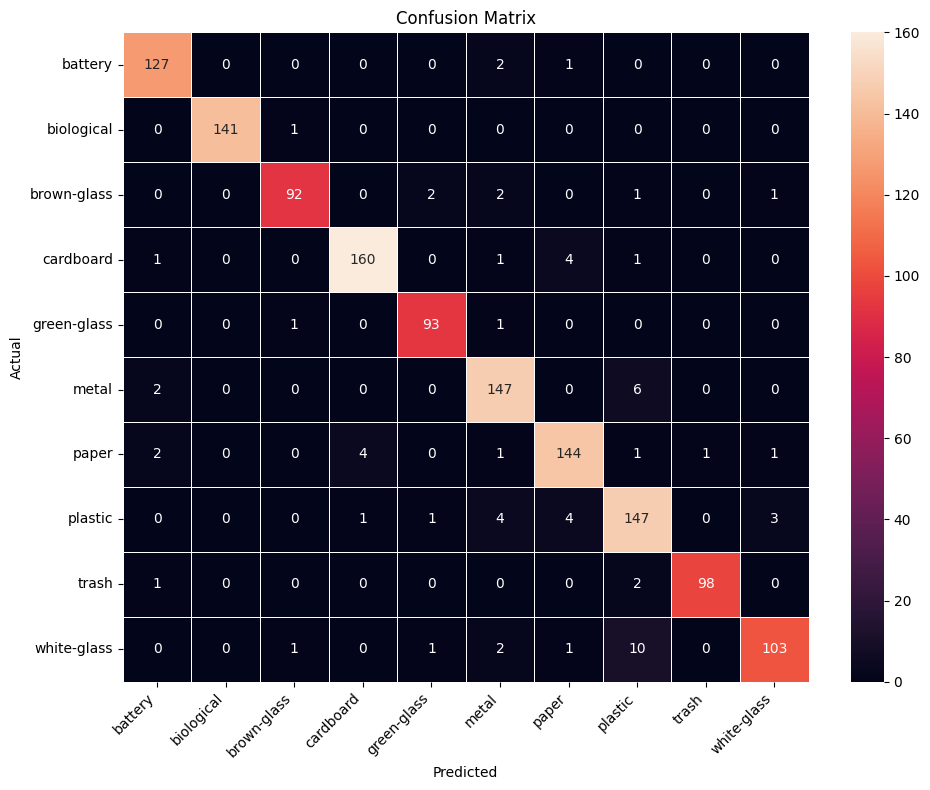

In [48]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5,
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("efficientnetb0_confusion_matrix.png", dpi=150)
plt.show()

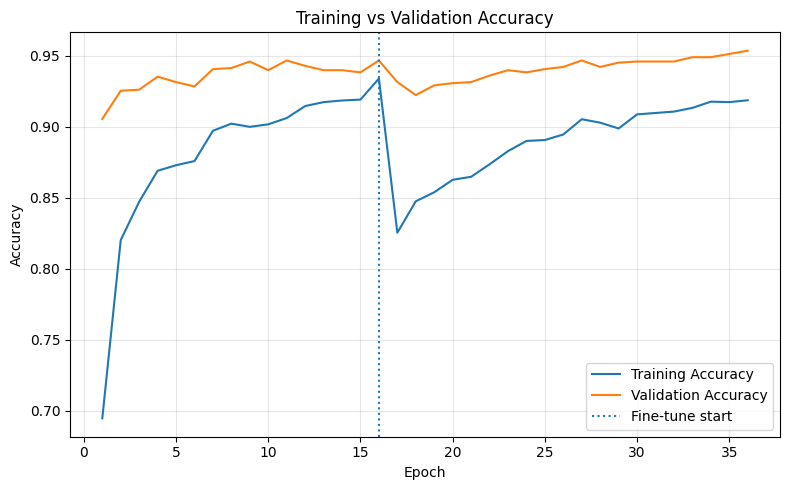

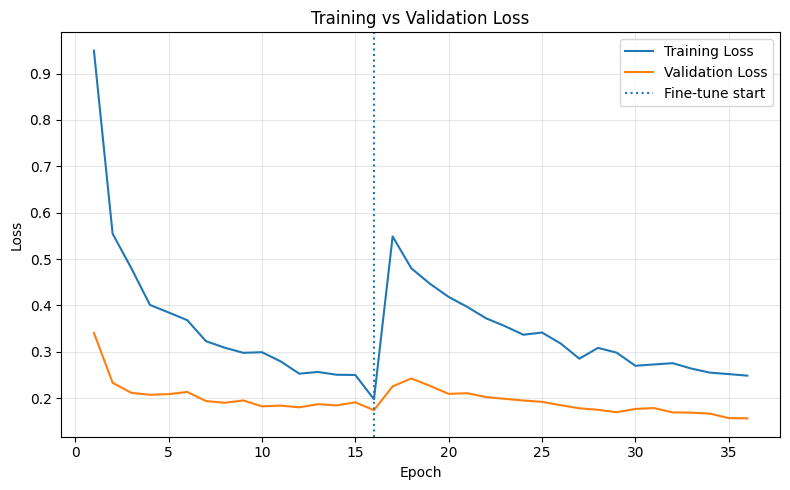

In [49]:
# Combine the frozen-base training history with the fine-tuning history.
acc = history.history["accuracy"] + history_fine.history["accuracy"]
val_acc = history.history["val_accuracy"] + history_fine.history["val_accuracy"]
loss = history.history["loss"] + history_fine.history["loss"]
val_loss = history.history["val_loss"] + history_fine.history["val_loss"]

epochs_range = range(1, len(acc) + 1)
fine_tune_start = len(history.history["accuracy"])

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, acc, label="Training Accuracy")
plt.plot(epochs_range, val_acc, label="Validation Accuracy")
plt.axvline(fine_tune_start, linestyle=":", label="Fine-tune start")
plt.legend()
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("efficientnetb0_accuracy_curve.png", dpi=150)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, loss, label="Training Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.axvline(fine_tune_start, linestyle=":", label="Fine-tune start")
plt.legend()
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("efficientnetb0_loss_curve.png", dpi=150)
plt.show()

In [50]:
SAVE_DIR = Path("/kaggle/working/efficientnetb0_garbage_model")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

model_path = SAVE_DIR / "garbage_efficientnetb0.keras"
classes_path = SAVE_DIR / "class_names.json"

model.save(model_path)

class_map = {str(i): name for i, name in enumerate(class_names)}
with open(classes_path, "w") as f:
    json.dump(class_map, f, indent=2)

print("Model saved to:", model_path)
print("Class names saved to:", classes_path)
print("Class map:", class_map)

Model saved to: /kaggle/working/efficientnetb0_garbage_model/garbage_efficientnetb0.keras
Class names saved to: /kaggle/working/efficientnetb0_garbage_model/class_names.json
Class map: {'0': 'battery', '1': 'biological', '2': 'brown-glass', '3': 'cardboard', '4': 'green-glass', '5': 'metal', '6': 'paper', '7': 'plastic', '8': 'trash', '9': 'white-glass'}


In [51]:
# Optional: predict one image by changing IMAGE_PATH.
from tensorflow.keras.preprocessing import image as keras_image

IMAGE_PATH = None  # Example: "/kaggle/input/your-image.jpg"

if IMAGE_PATH is not None:
    img = keras_image.load_img(IMAGE_PATH, target_size=IMG_SIZE)
    arr = keras_image.img_to_array(img)
    arr = np.expand_dims(arr, axis=0)

    preds = model.predict(arr, verbose=0)[0]
    pred_index = int(np.argmax(preds))
    pred_class = class_names[pred_index]
    confidence = preds[pred_index] * 100

    top3 = sorted(enumerate(preds), key=lambda x: x[1], reverse=True)[:3]

    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Predicted: {pred_class} ({confidence:.1f}%)")
    plt.tight_layout()
    plt.show()

    print(f"Class: {pred_class}")
    print(f"Confidence: {confidence:.2f}%")
    print("Top 3 predictions:")
    for idx, score in top3:
        print(f"  {class_names[idx]:20s} {score * 100:6.2f}%")
else:
    print("Set IMAGE_PATH to test a single image.")

Set IMAGE_PATH to test a single image.


## Streamlit Application

The trained EfficientNetB0 model is integrated into a separate Streamlit application.

The application source code is available in:

[Open app.py](app.py)

The application supports:

- Waste-image upload
- Classification across 10 waste categories
- Prediction confidence
- Class-probability visualization
- Disposal guidance
- Optional Groq-powered recycling assistance